# 03_EDA_404_BRAIN_NOT_FOUND
Vietnam Fashion E-Commerce · Exploratory Data Analysis · 2012 – 2022

## Bối Cảnh và Mục Tiêu Kinh Doanh

Một doanh nghiệp thời trang thương mại điện tử tại Việt Nam đã tích lũy hơn 10 năm dữ liệu giao dịch, bao gồm đơn hàng, tồn kho, khuyến mãi và hành vi khách hàng. Tuy nhiên, họ đang đối mặt với ba áp lực lớn:

1. **Tồn kho mất cân đối:** Hiện tượng thiếu hàng (Stockout) và thừa hàng (Overstock) xảy ra đồng thời, gây tổn thất doanh thu biểu kiến và làm kẹt nguồn vốn lưu động.
2. **Chi phí hoàn hàng (Return cost) leo thang:** Tỷ lệ trả hàng cao đang làm giảm biên lợi nhuận ròng của doanh nghiệp.
3. **Dự báo nhu cầu (Demand Forecasting) kém chính xác:** Đội ngũ vận hành không chủ động được lượng hàng cần chuẩn bị trong các mùa cao điểm.

**Mục tiêu của phần phân tích này:** Khám phá cấu trúc dữ liệu, nhận diện các vấn đề (bottlenecks) thông qua số liệu định lượng, kiểm chứng các giả thuyết kinh doanh và xây dựng bộ đặc trưng chuẩn bị cho mô hình dự báo doanh thu.

## Cấu Trúc Khám Phá Dữ Liệu (EDA)
bo sung

## Glossary: Các thuật ngữ chính

| Thuật ngữ | Định nghĩa |
|-----------|-----------|
| **Stockout** | Tình trạng hết hàng, không thể đáp ứng nhu cầu khách hàng |
| **Overstock** | Tình trạng thừa hàng, vốn bị khóa, rủi ro lỗi mùa |
| **Fill Rate** | Tỷ lệ đơn vị được cấp từ kho so với nhu cầu |
| **Lead Time** | Thời gian từ lúc tạo đơn đến khi giao hàng |
| **AOV (Avg Order Value)** | Giá trị trung bình của mỗi đơn hàng |
| **Return Rate** | Tỷ lệ số sản phẩm bị trả lại so với tổng số bán |
| **Gross Margin** | (Doanh thu - COGS) / Doanh thu |
| **Penetration Rate** | Tỷ lệ dòng giao dịch áp dụng khuyến mãi |

## Metric Definitions: Cách tính toán chính

- **Tổng Doanh Thu:** Sum(Revenue) từ tất cả đơn hàng
- **Gross Margin:** (Sum(Revenue) - Sum(COGS)) / Sum(Revenue) × 100%
- **Tỷ lệ Hủy Đơn:** Count(order_status='cancelled') / Total Orders × 100%
- **Tỷ lệ Hoàn Hàng:** Count(Returned Orders) / Total Orders × 100%
- **Estimated Lost Revenue (Stockout):** Sum(stockout_days × avg_daily_revenue)
- **RFM Segments:** Champions, Loyal, At-Risk, Lost

In [46]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
from pathlib import Path



ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import src.eda_utils
importlib.reload(src.eda_utils)

from src.eda_utils import *

set_plot_style()
print(f'Save figures to: {FIG_DIR}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Save figures to: D:\Study\HCMUS\My Project\Datathon\DATATHON_2026\figures


---

## Setup & Load dữ liệu

In [47]:
dfs = load_datasets()
master_df = prepare_master_df(dfs)

print('Loaded')

Loaded


---

## 1. Tổng quan doanh nghiệp

Phần này cung cấp các chỉ số chiến lược (KPI cards), xu hướng doanh thu qua thời gian, phân phối trạng thái đơn hàng, vấn đề tồn kho theo phân khúc, và so sánh traffic vs revenue.

In [48]:
section_header('KPI tổng quan doanh nghiệp', 'Các chỉ số chiến lược quản lý hiệu suất kinh doanh')
business_kpis = build_business_kpis(master_df, dfs)
kpi_cards = build_kpi_cards(business_kpis)
display_kpi_cards(kpi_cards)

### nhan xet

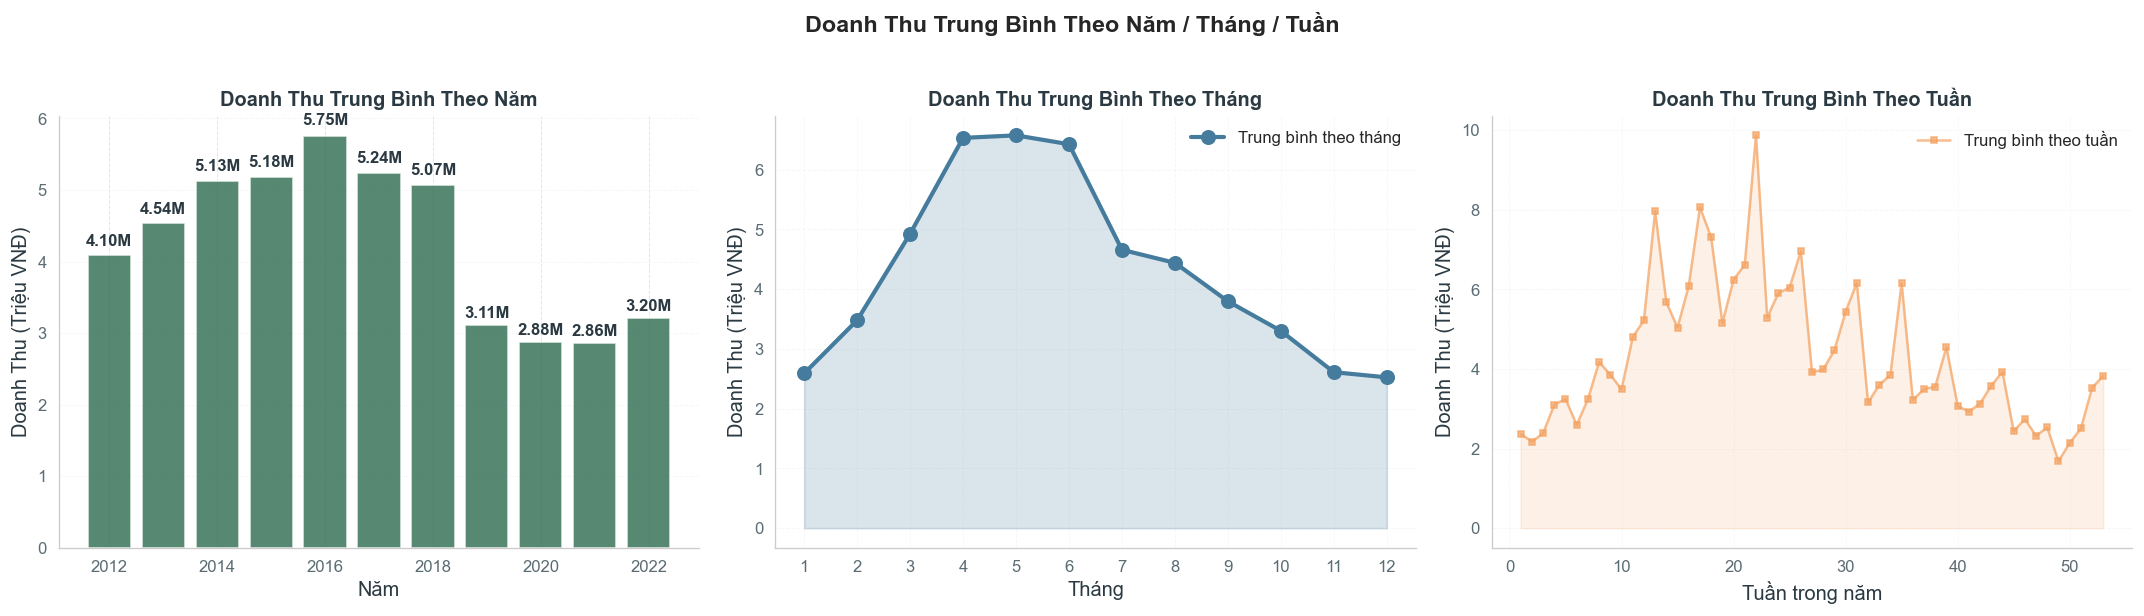

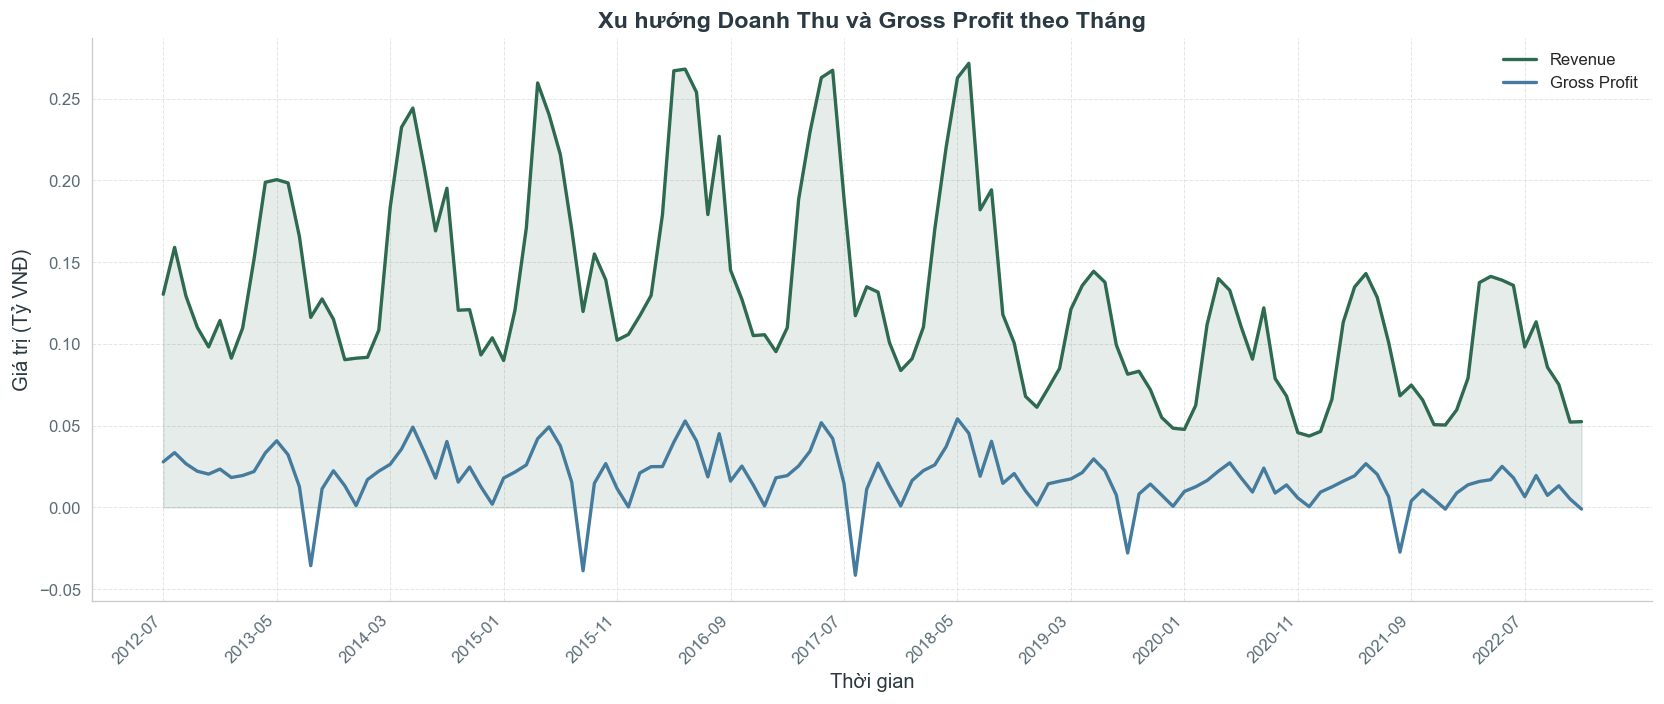

In [49]:
section_header('Trung bình doanh thu theo kỳ hạn', 'Phân tích doanh thu trung bình theo năm, tháng, tuần')
plot_revenue_averages_by_period(dfs)
section_header('Xu hướng tài chính', 'Doanh thu và lợi nhuận theo tháng từ dataset sales.csv')
plot_sales_time_series(dfs['sales'])

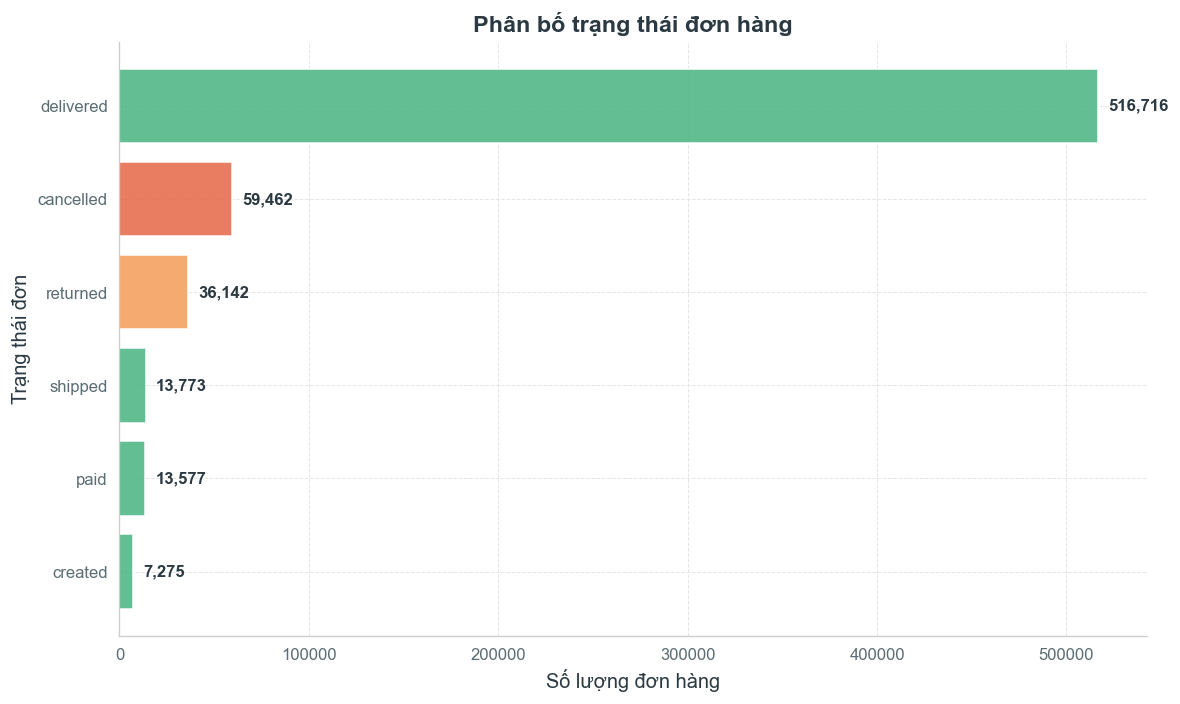

In [50]:
section_header('Bottleneck đơn hàng', 'Phân phối trạng thái đơn hàng giúp xác định điểm nghẽn kinh doanh')
plot_order_status_distribution(dfs['orders'])

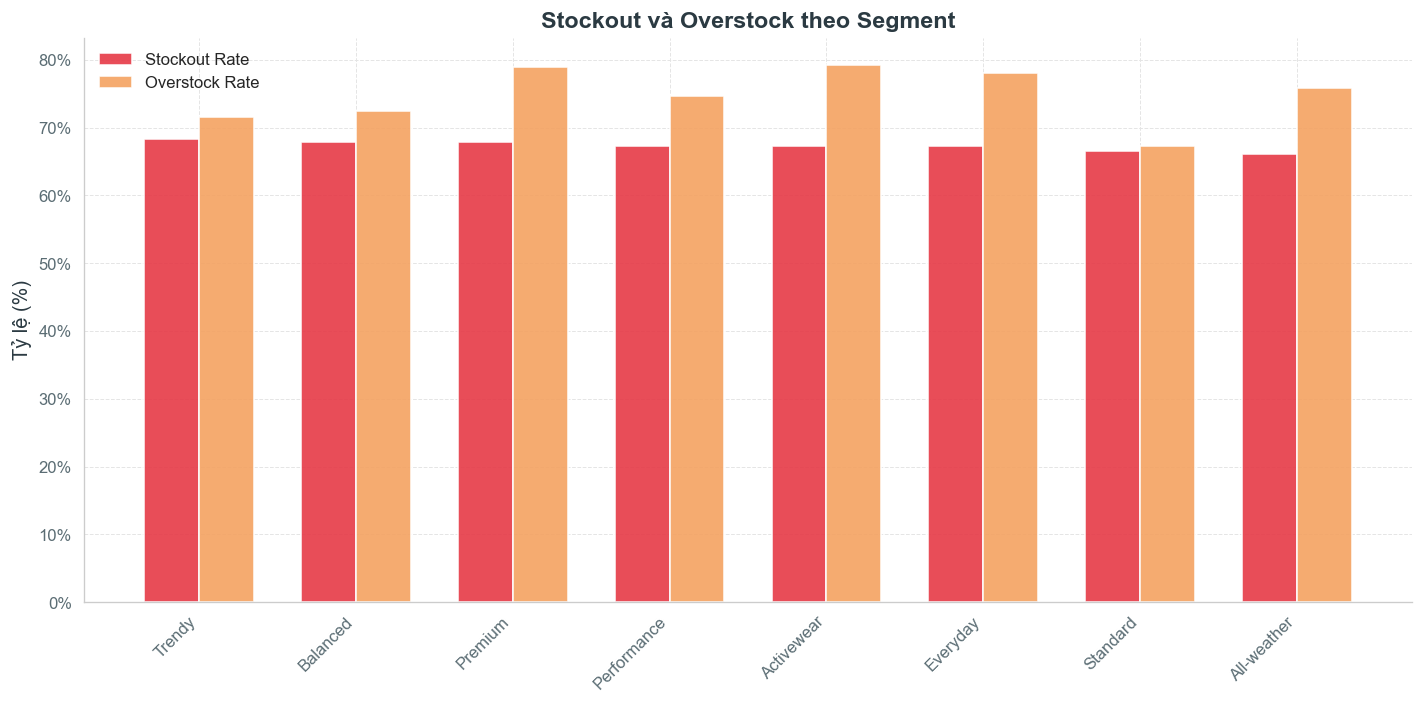

In [51]:
section_header('Vấn đề tồn kho', 'So sánh stockout và overstock theo phân khúc sản phẩm')
plot_stockout_overstock_segment(dfs['inventory'], dfs['products'])

### nhan xet

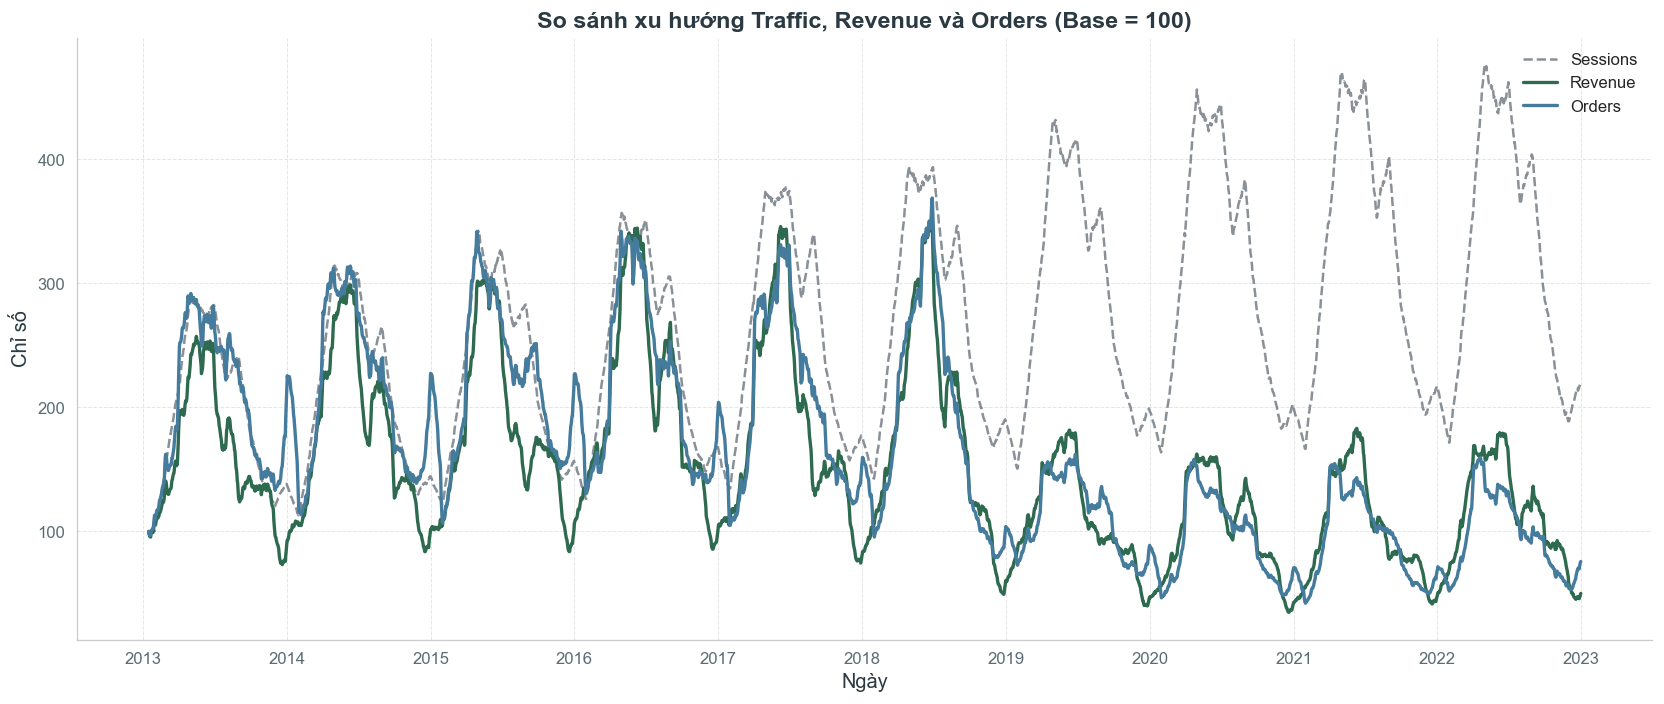

In [52]:
section_header('Traffic vs Revenue', 'So sánh xu hướng traffic, revenue và orders đã chuẩn hóa')
plot_traffic_revenue_indexed(master_df, dfs['traffic'])

---

## 2. Huỷ đơn, hoàn hàng

Phần này phân tích chi tiết về các đơn hàng bị hủy, trả lại, lý do hoàn hàng, tác động của lead time đến đánh giá khách hàng, và ước tính thiệt hại doanh thu do các vấn đề này.

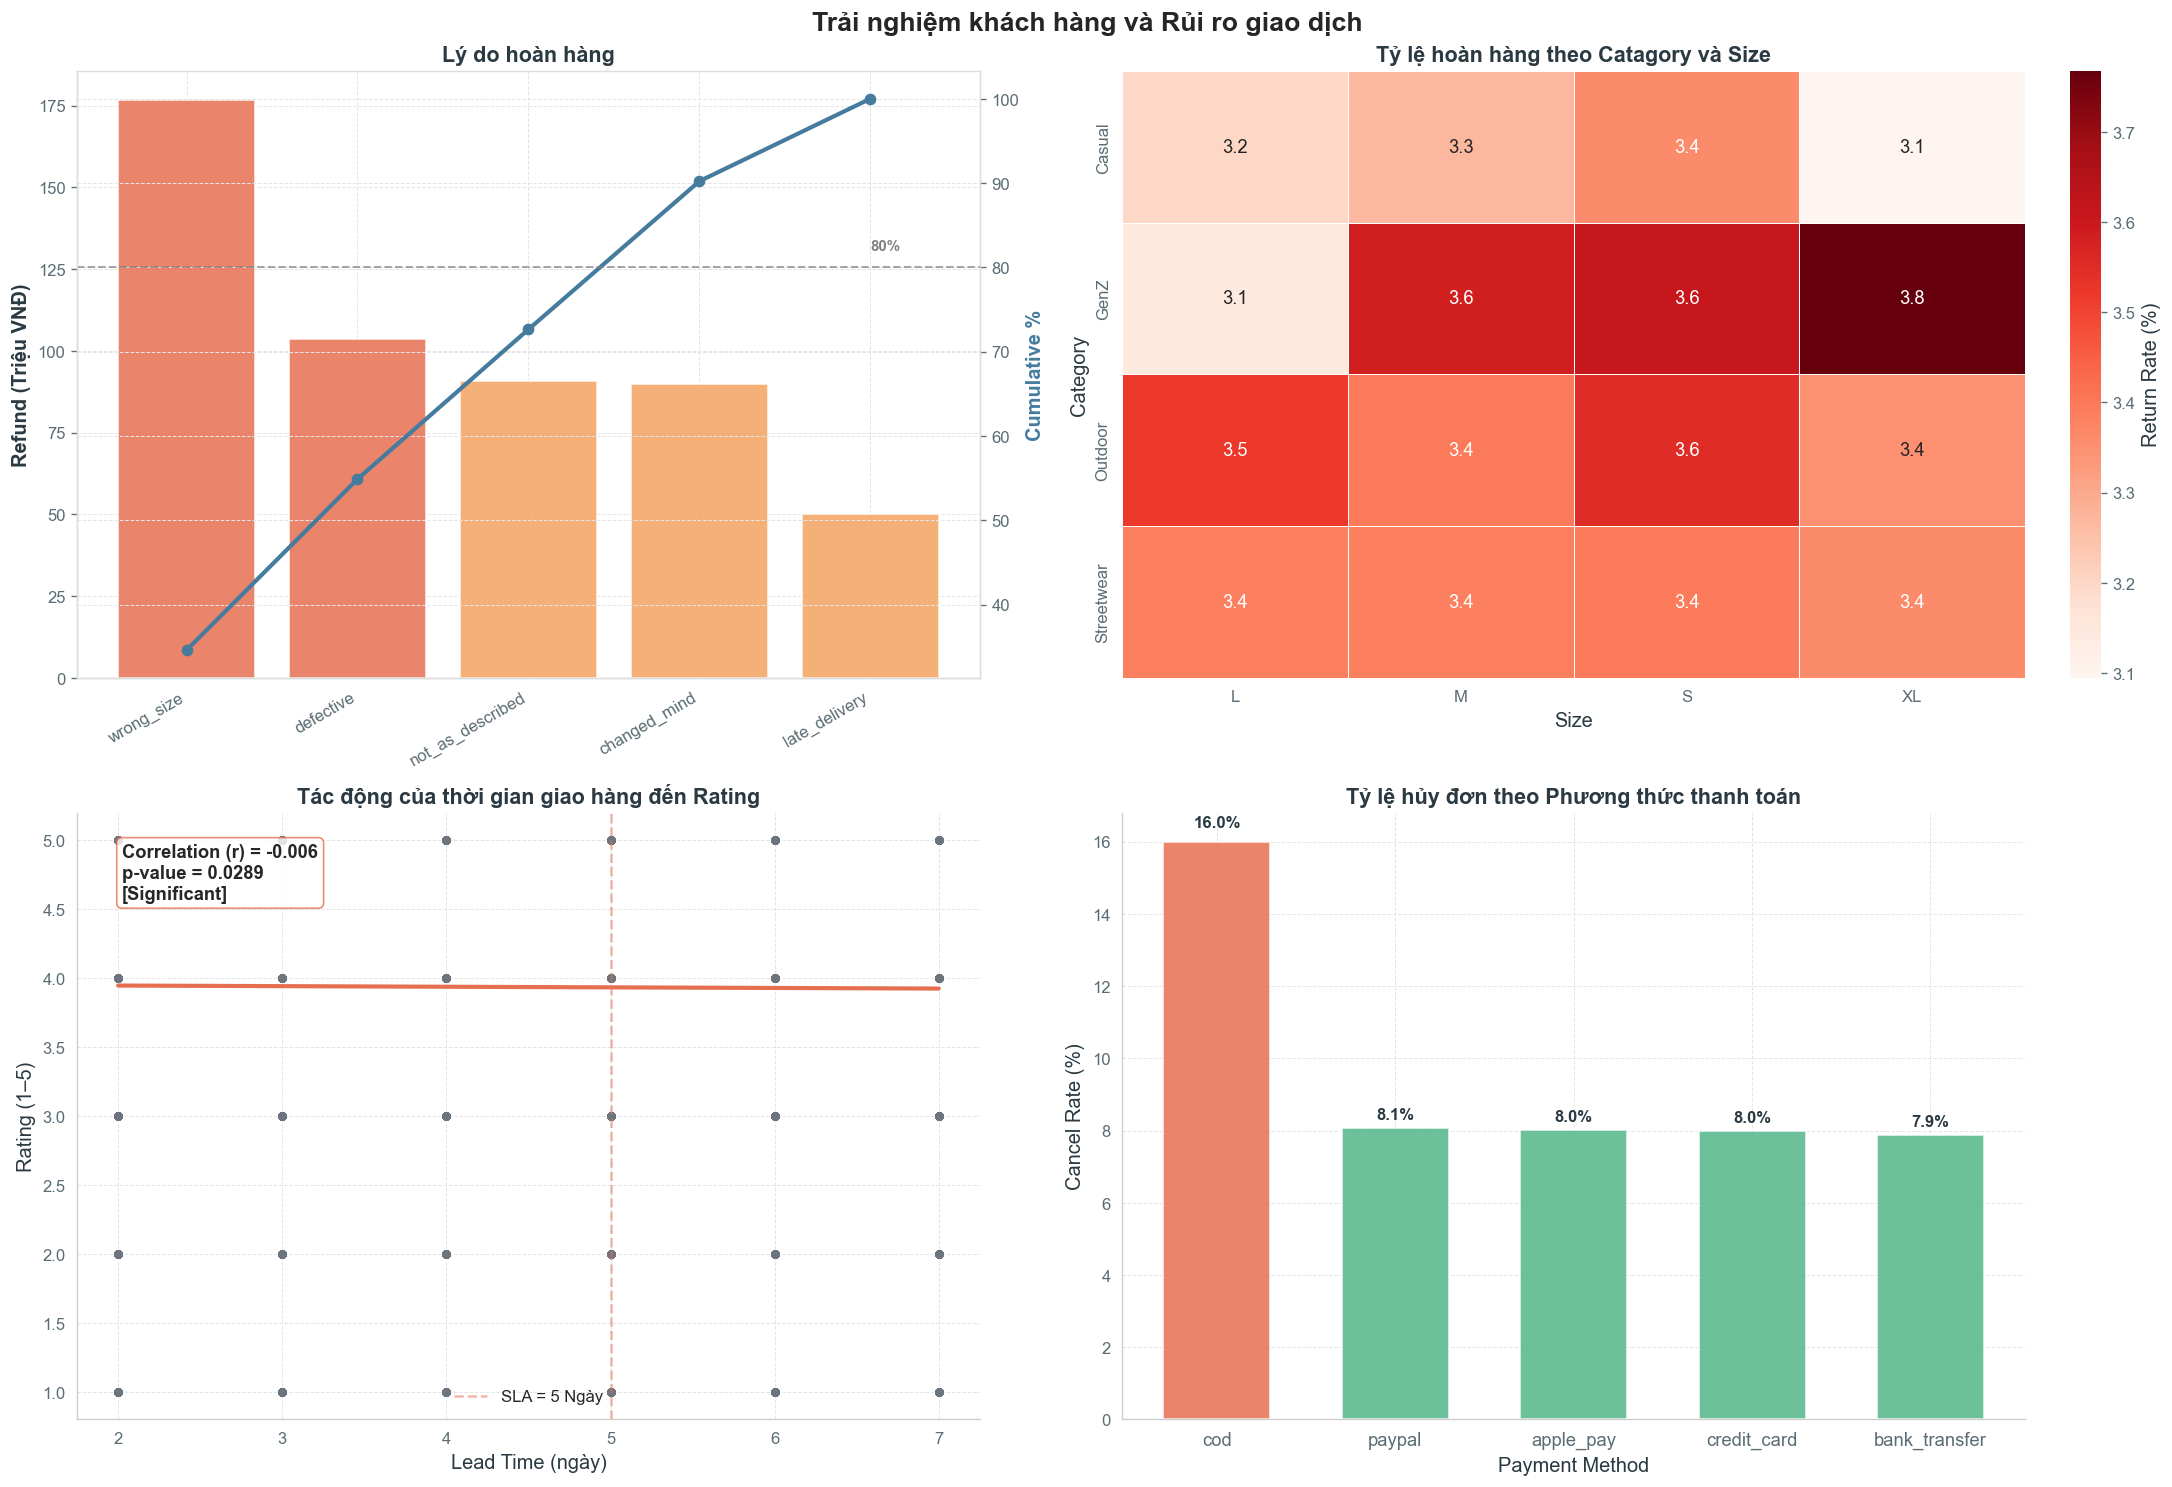

In [53]:
section_header('Phân tích Rủi ro Vận hành & Trải nghiệm Khách hàng', 'Đánh giá chuyên sâu về điểm nghẽn trong khâu giao hàng, lý do hoàn trả và tỷ lệ hủy đơn')

plot_returns_cancellations_deepdive(
    returns=dfs['returns'], 
    products=dfs['products'], 
    order_items=dfs['order_items'], 
    reviews=dfs['reviews'], 
    shipments=dfs['shipments'], 
    orders=dfs['orders'], 
    save_fig=True
)

### nhan xet

---

## 3. Stockout, Overstock

Phần này cung cấp cái nhìn toàn diện về sức khỏe tồn kho (Health Overview), xác định nơi tập trung rủi ro, ước tính doanh thu bị mất do thiếu hàng, lượng vốn bị khóa trong thừa hàng, và các kịch bản thu hồi doanh thu.

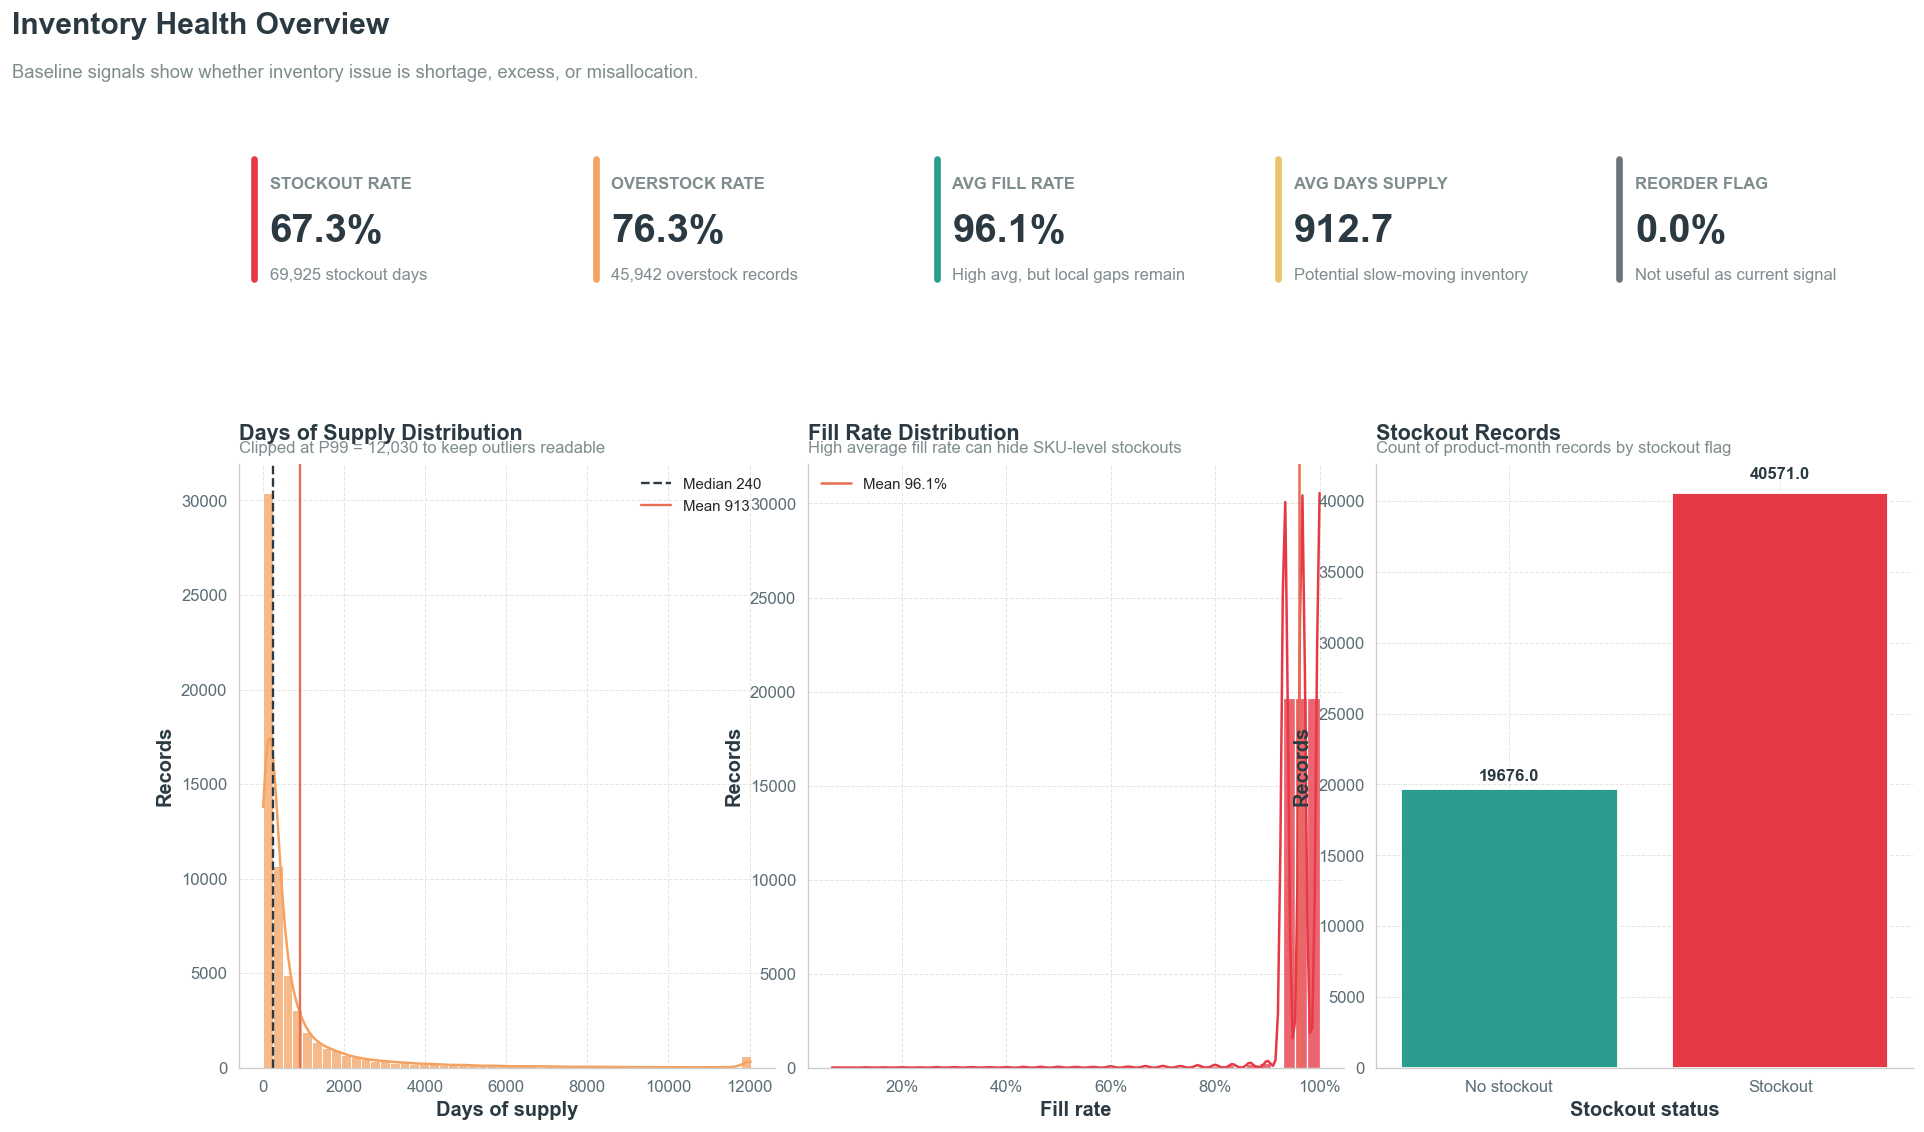

In [54]:
section_header(
    title='Phân tích Vận hành: Sức khỏe Tồn kho (Inventory Health)', 
    subtitle='Đánh giá rủi ro đứt gãy chuỗi cung ứng và tồn kho dư thừa'
)

# Gọi hàm với dữ liệu inventory
plot_inventory_health_overview(inv=dfs['inventory'], save_fig=True)

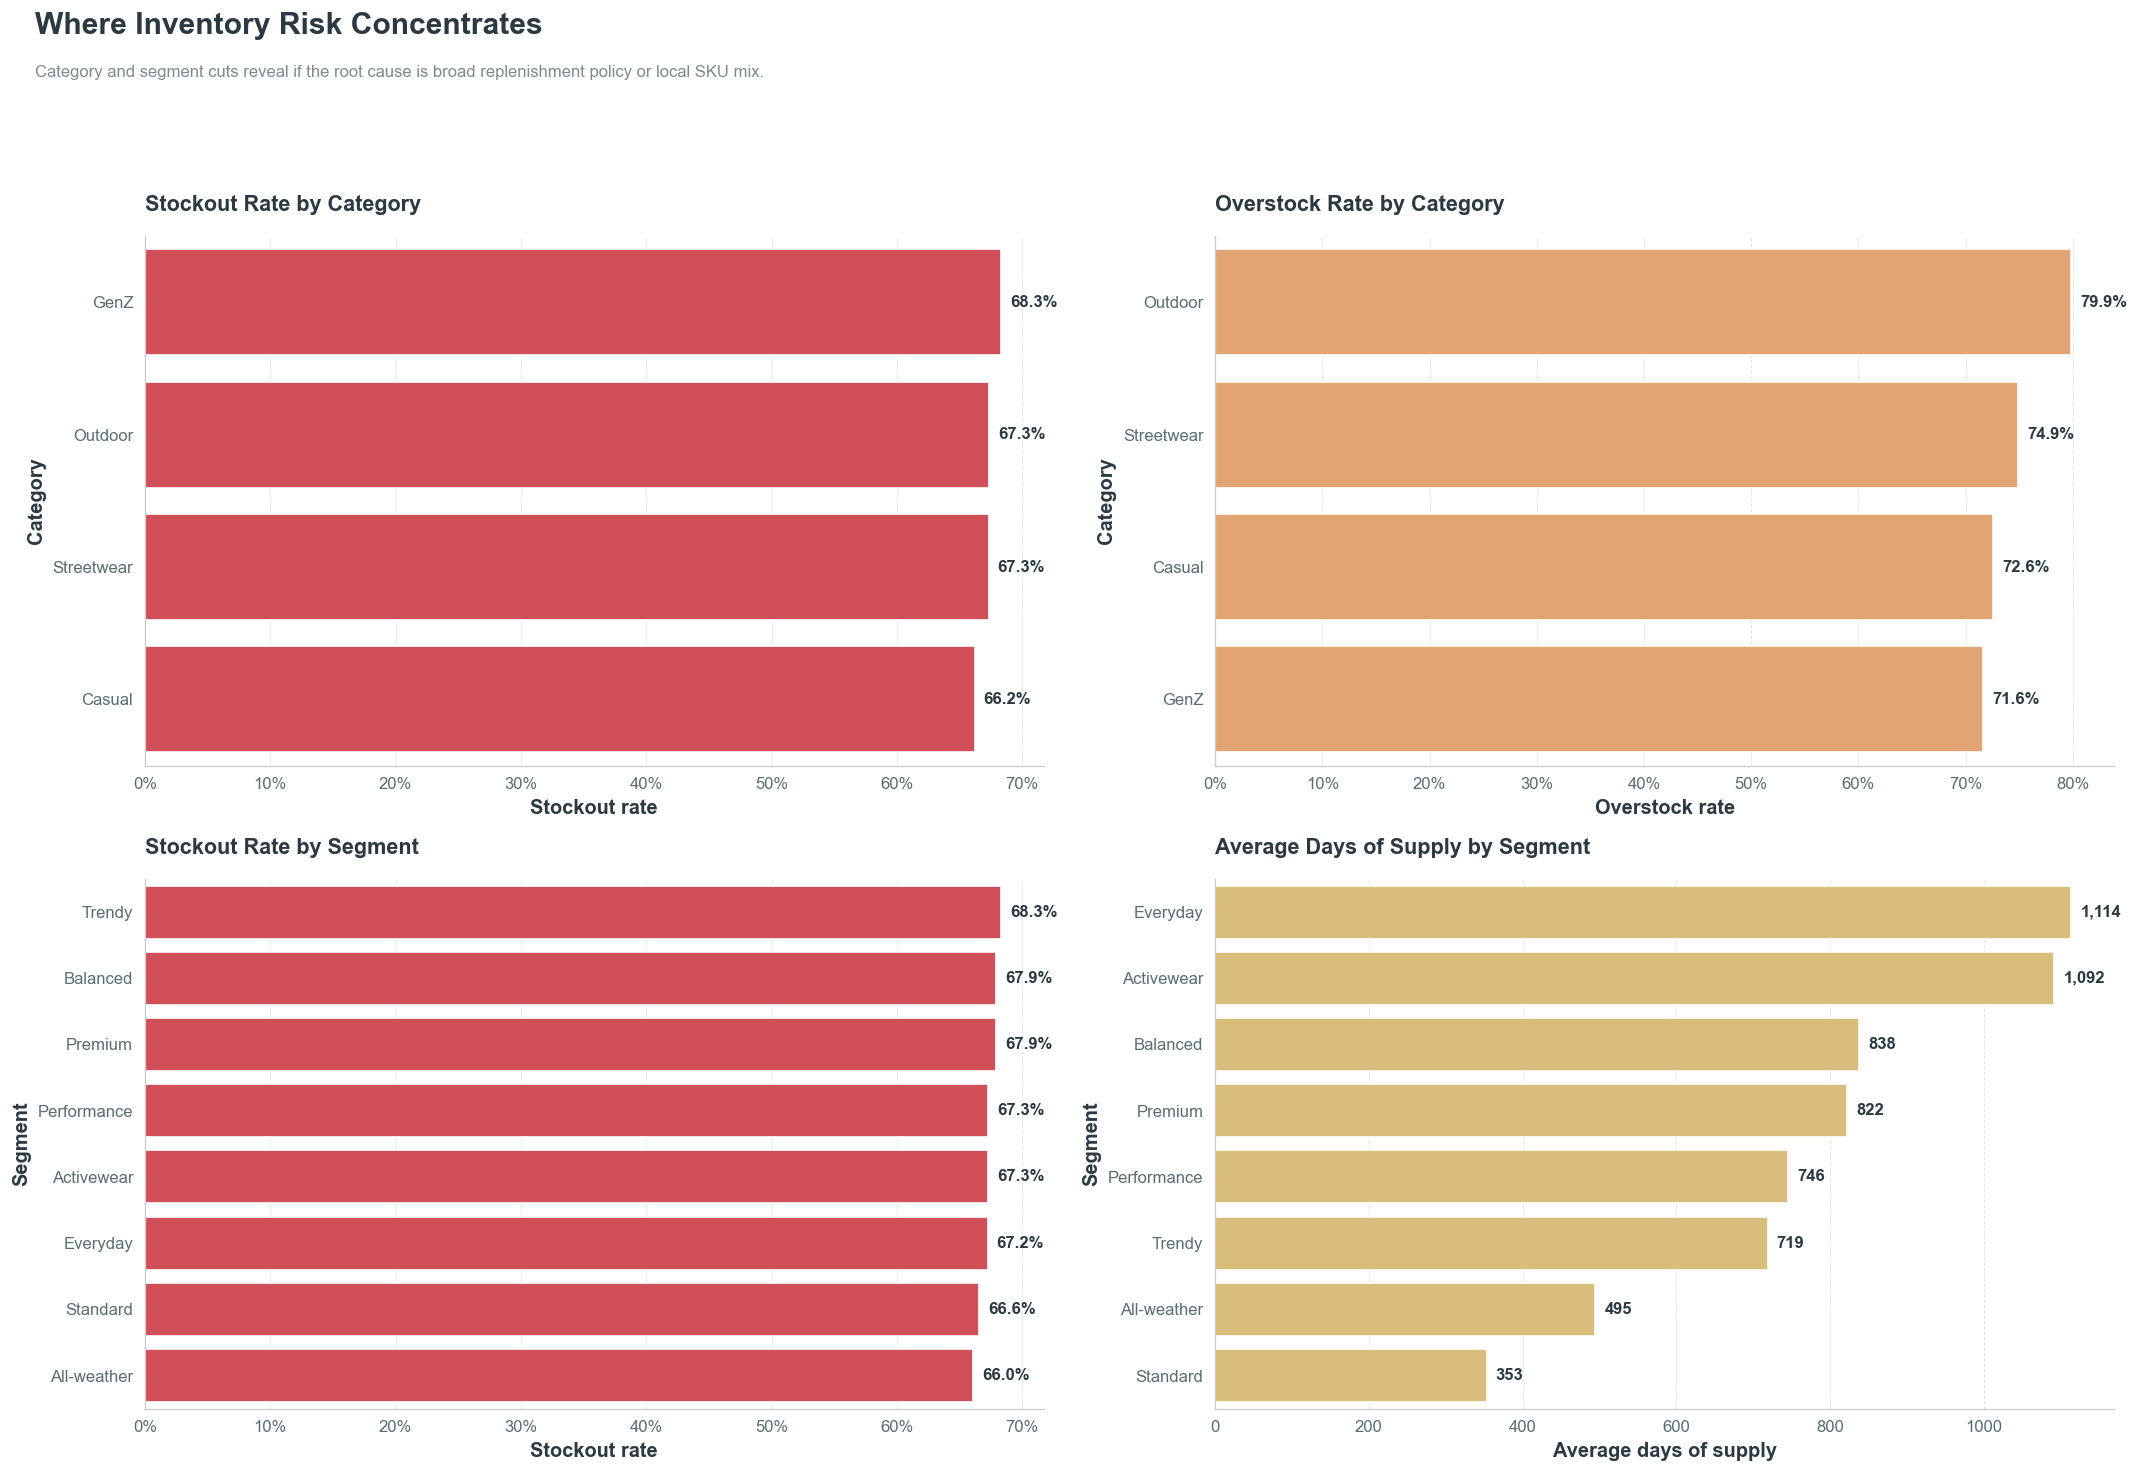

In [55]:
section_header(
    title='Định vị Điểm nghẽn Chuỗi cung ứng', 
    subtitle='Khoanh vùng rủi ro thiếu/thừa hàng hóa theo từng Nhóm và Phân khúc sản phẩm'
)

plot_inventory_risk_concentration(
    inventory=dfs['inventory'], 
    save_fig=True
)

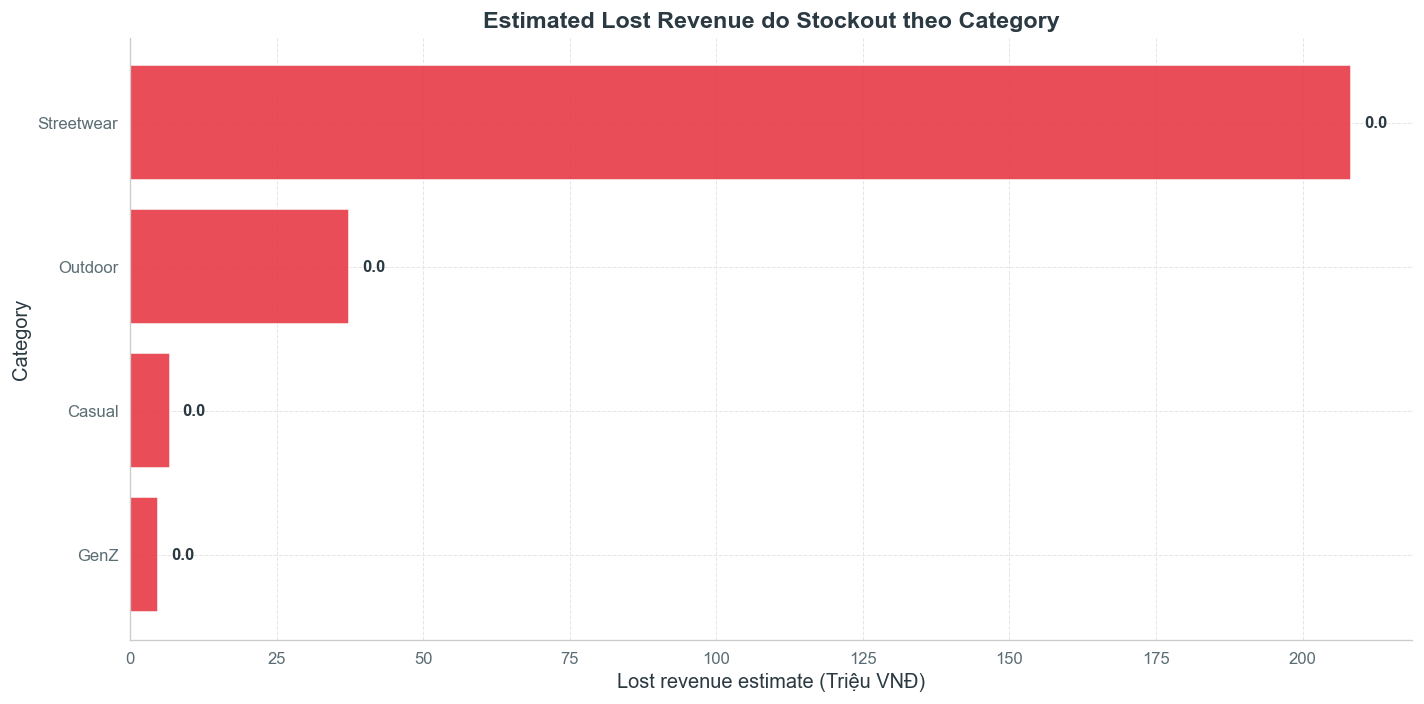

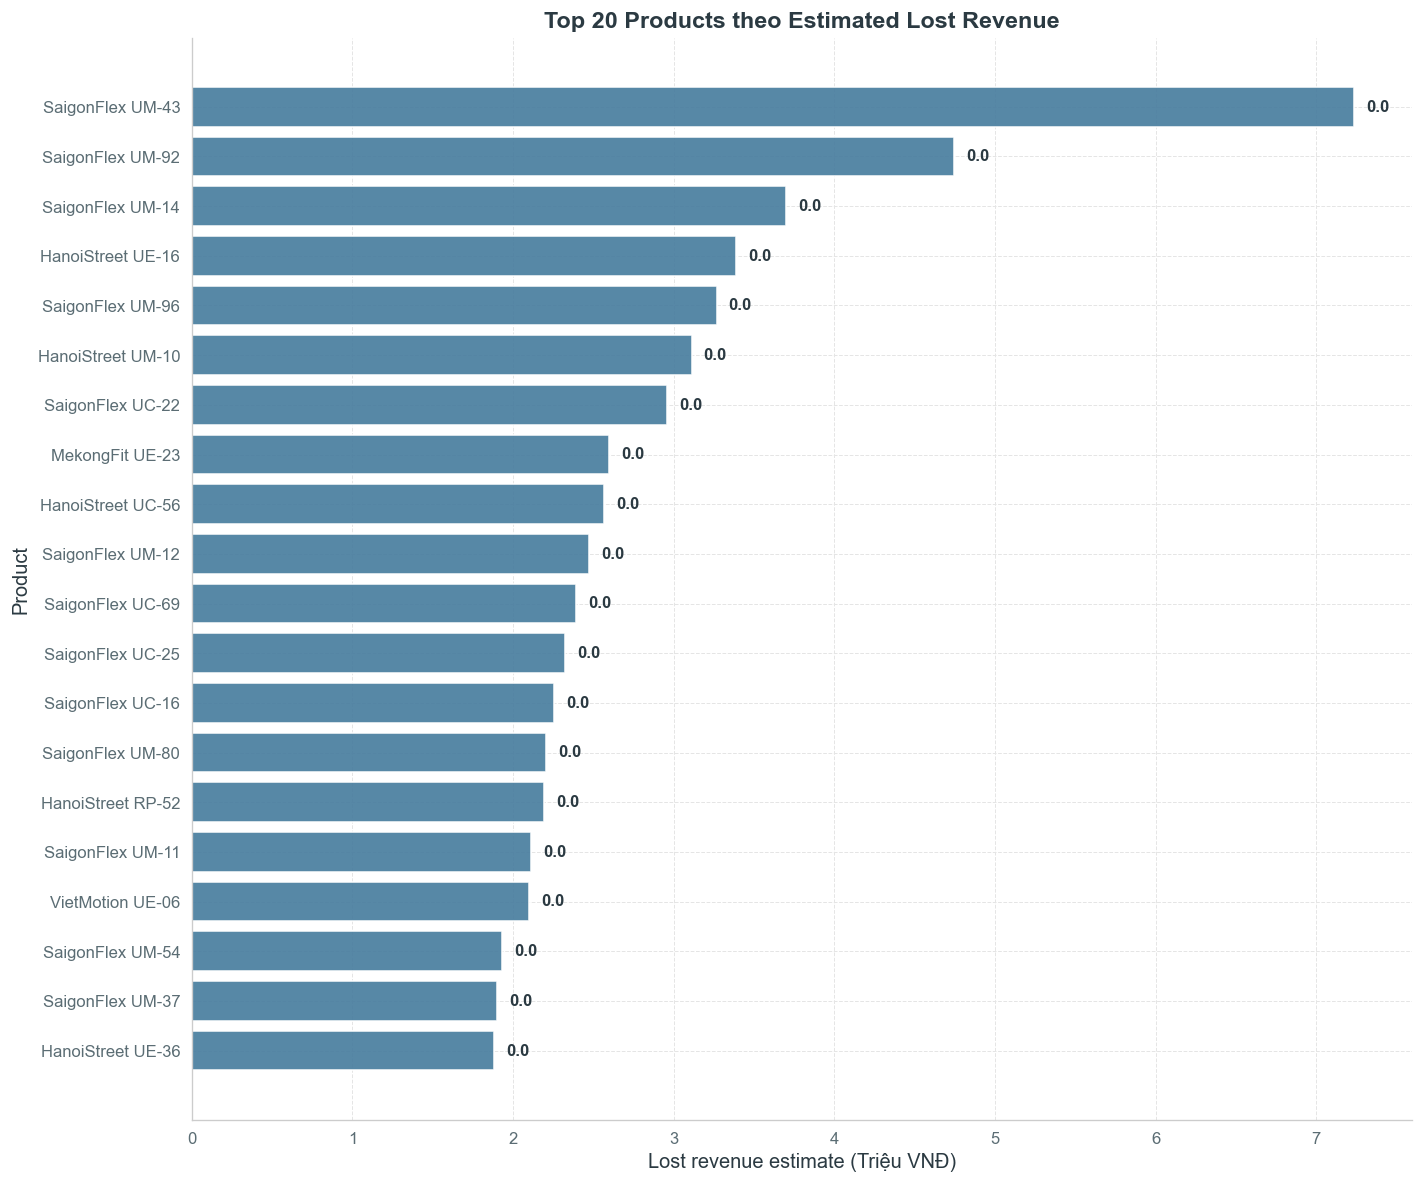

In [56]:
section_header('Impact của stockout', 'Ước tính thiệt hại doanh thu do hàng hết kệ')
stockout_loss_df = estimate_stockout_impact(dfs['inventory'], dfs['products'])
plot_stockout_loss_by_category(stockout_loss_df)
plot_top_products_lost_revenue(stockout_loss_df, top_n=20)

** Dư hàng và vốn bị khóa**

Nếu chỉ nhìn phần doanh thu bị mất, ta có thể vội kết luận rằng cần nhập thêm hàng. Nhưng điều đó nguy hiểm, vì doanh nghiệp cũng đang có tình trạng dư hàng.

Phần này trả lời câu hỏi: **bao nhiêu tiền vốn đang bị nằm trong hàng dư?**

Vốn bị khóa là vấn đề quan trọng vì tiền nằm trong kho không thể dùng cho sản phẩm bán tốt hơn, marketing, vận hành hoặc các cơ hội kinh doanh khác. Với ngành thời trang, hàng để quá lâu còn có nguy cơ lỗi mùa, lỗi xu hướng và phải giảm giá.

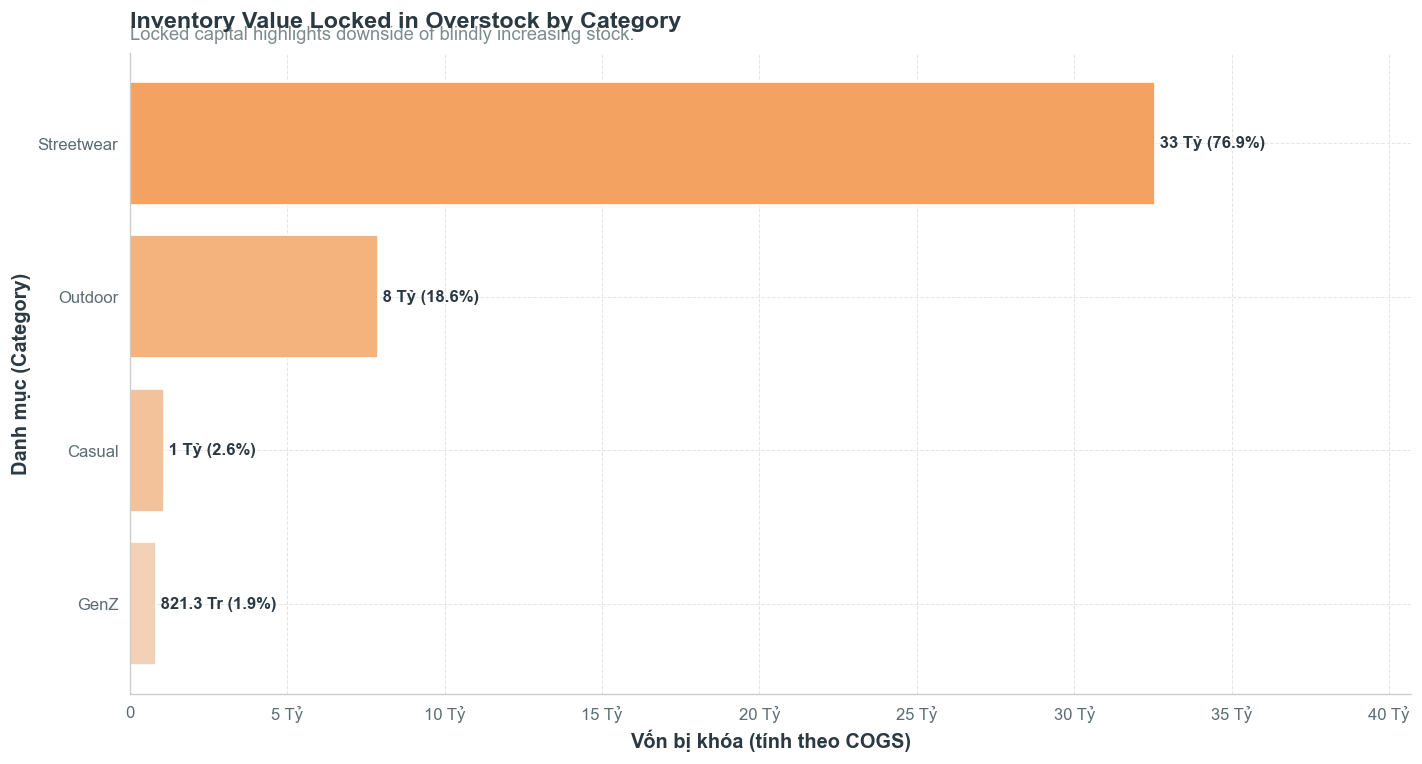

In [57]:
section_header(
    title='Phân tích Rủi ro: Dư hàng và Vốn bị khóa', 
    subtitle='Định lượng rủi ro kẹt vốn theo từng Category để điều chỉnh chiến lược nhập hàng'
)

# Cần truyền vào cả dfs['inventory'] và dfs['products'] để tính toán COGS
plot_overstock_capital_locked(inventory=dfs['inventory'], products=dfs['products'], save_fig=True)

### Kịch bản thu hồi doanh thu: simple upside estimate

Phần này giữ lại cách tính đơn giản ban đầu để tạo cảm giác về quy mô cơ hội. Tuy nhiên, cần nói rõ đây là **ước tính tuyến tính đơn giản**, không phải forecast.

Giảm thiếu hàng 20% không tự động đồng nghĩa thu hồi 20% doanh thu bị mất. Một phần khách hàng có thể đã mua sản phẩm khác, rời đi, hoặc nhu cầu đã mất vĩnh viễn. Vì vậy phần sau sẽ thêm scenario thực tế hơn với recovery rate và cannibalization.

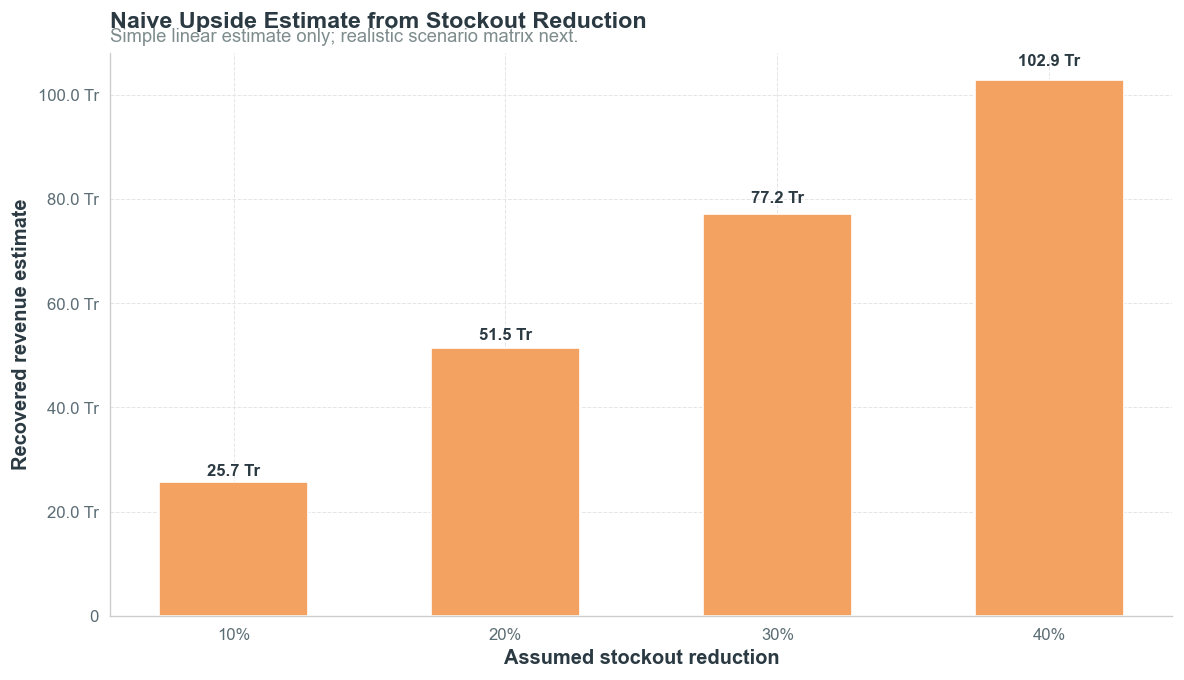

,Mức giảm stockout giả định,Recovered revenue estimate,Recovered gross margin estimate
0,0.1,2.573517e+07,5.000518e+06
1,0.2,5.147033e+07,1.000104e+07
2,0.3,7.720550e+07,1.500155e+07
3,0.4,1.029407e+08,2.000207e+07


In [58]:
section_header(
    title='Dự phóng Kinh doanh: Tiềm năng Thu hồi Doanh thu', 
    subtitle='Ước tính quy mô dòng tiền thu hồi được khi cải thiện năng lực cung ứng (Giảm Stockout)'
)

# Chạy mô hình giả định và lưu biểu đồ
recovery_scenario_df = plot_stockout_recovery_scenarios(
    inventory=dfs['inventory'], 
    products=dfs['products'], 
    save_fig=True
)

# Hiển thị bảng số liệu chi tiết để xem thêm phần Gross Margin
display(recovery_scenario_df)

---

## 4. Khuyến mãi

Phần này phân tích tác động của khuyến mãi lên biên lợi nhuận, so sánh margin giữa các loại khuyến mãi (percentage vs fixed), và kiểm chứng xem khuyến mãi có giúp tăng doanh số hay chỉ làm giảm lợi nhuận.

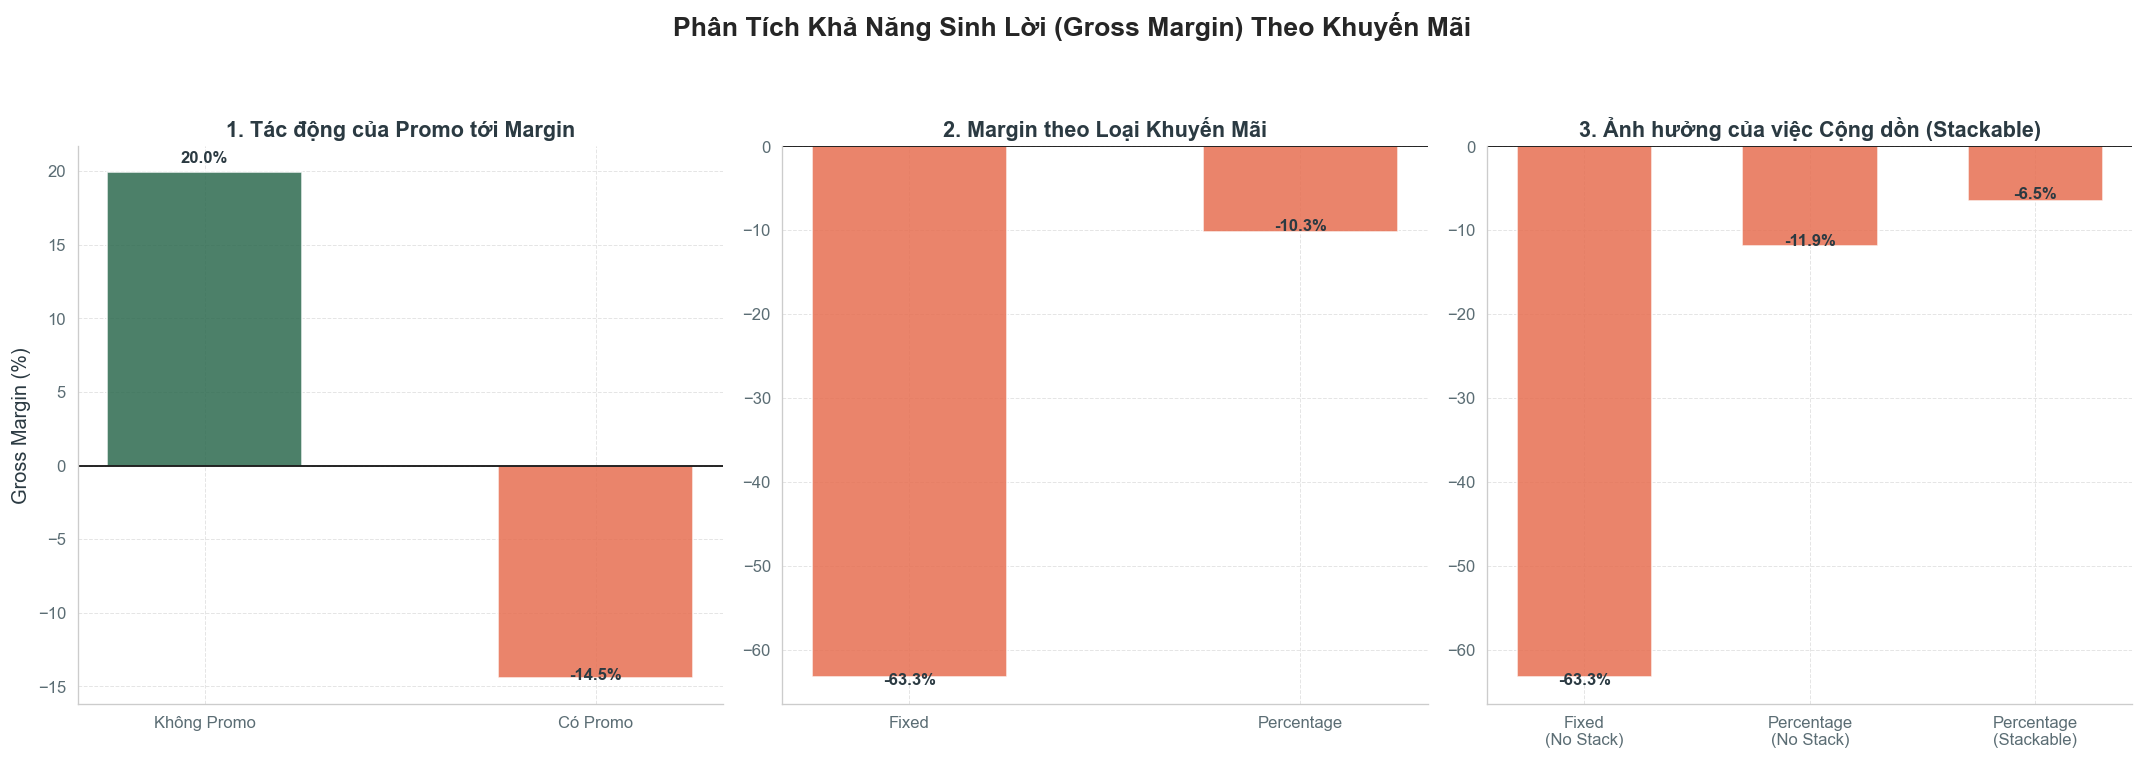

In [59]:
section_header('Phân tích khuyến mãi', 'So sánh biên lợi nhuận giữa đơn hàng có và không có khuyến mãi')
promo_summary = compute_promotion_margins(master_df)
# print(f"Tỷ lệ dòng có khuyến mãi: {promo_summary['penetration_rate']:.1f}%")
# print(f"Margin trung bình không promo: {promo_summary['margin_without_promo']:.1f}%")
# print(f"Margin trung bình có promo: {promo_summary['margin_with_promo']:.1f}%")
# display(promo_summary['by_type'])
# display(promo_summary['stackable_breakdown'])

plot_promotion_margins_analysis(promo_summary)

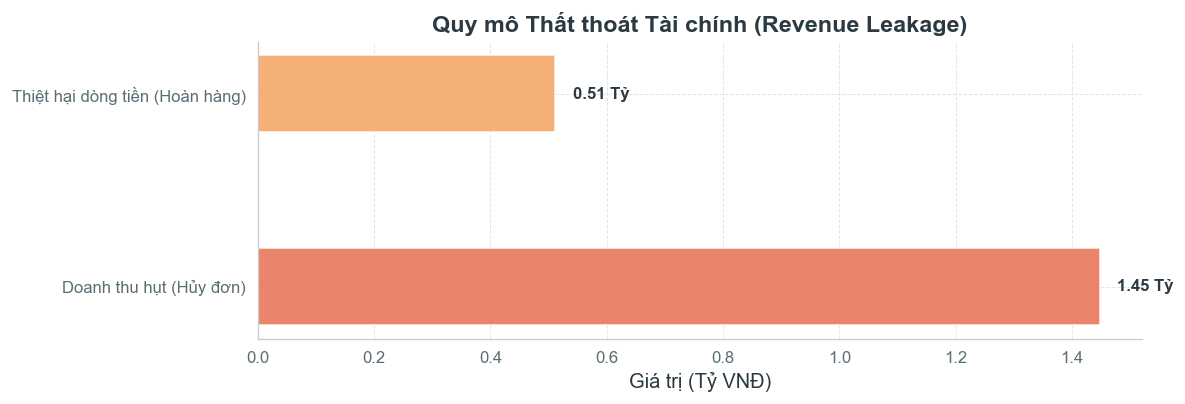

In [60]:
section_header(
    title='Định lượng Tổn thất Tài chính (Revenue Leakage)', 
    subtitle='Quy đổi tỷ lệ Hủy đơn và Hoàn hàng thành thiệt hại dòng tiền và chi phí cơ hội thực tế'
)

# Khởi chạy tính toán và lưu kết quả vào biến leakage_metrics
leakage_metrics = plot_revenue_leakage_impact(
    master_df=master_df, 
    returns=dfs['returns'], 
    shipments=dfs['shipments'], 
    save_fig=True
)

---

## 5. Tỷ lệ giữ chân khách hàng

Phần này phân tích RFM (Recency, Frequency, Monetary), phân nhóm khách hàng, tỷ lệ một lần mua, khách hàng mới vs khách cũ, và tìm hiểu xu hướng churn & retention để xác định các nhóm khách cần chăm sóc đặc biệt.

In [61]:
section_header('Phân tích khách hàng', 'RFM và tỷ lệ khách hàng 1 lần / khách mới - khách cũ')
customer_rfm = build_customer_rfm(master_df)
customer_lifecycle = compute_customer_lifecycle(master_df)
print(f"Tỷ lệ khách hàng mua 1 lần: {customer_lifecycle['one_time_customer_rate']:.1f}%")
display(customer_rfm.groupby('segment').agg(count=('customer_id','count'), avg_recency=('recency','mean'), avg_profit=('monetary_profit','mean')).reset_index())
display(customer_lifecycle['cohort_by_year'])

Tỷ lệ khách hàng mua 1 lần: 24.8%


,segment,count,avg_recency,avg_profit
0,At Risk,3247,1759.999076,19513.720474
1,Champions,25213,263.797009,38690.862569
2,Lost,25705,2513.251858,3180.074840
3,Loyal Customers,18542,782.778449,16146.446120
4,Need Attention,12670,1590.445462,6480.574939
5,New Customers,4869,341.289998,3143.328357


,order_year,total_customers,new_customers
0,2012,22068,22068
1,2013,39384,25099
2,2014,40376,13293
3,2015,40807,8828
4,2016,40933,6392
5,2017,39651,4789
6,2018,37922,3717
7,2019,27312,1898
8,2020,24335,1500
9,2021,23984,1340


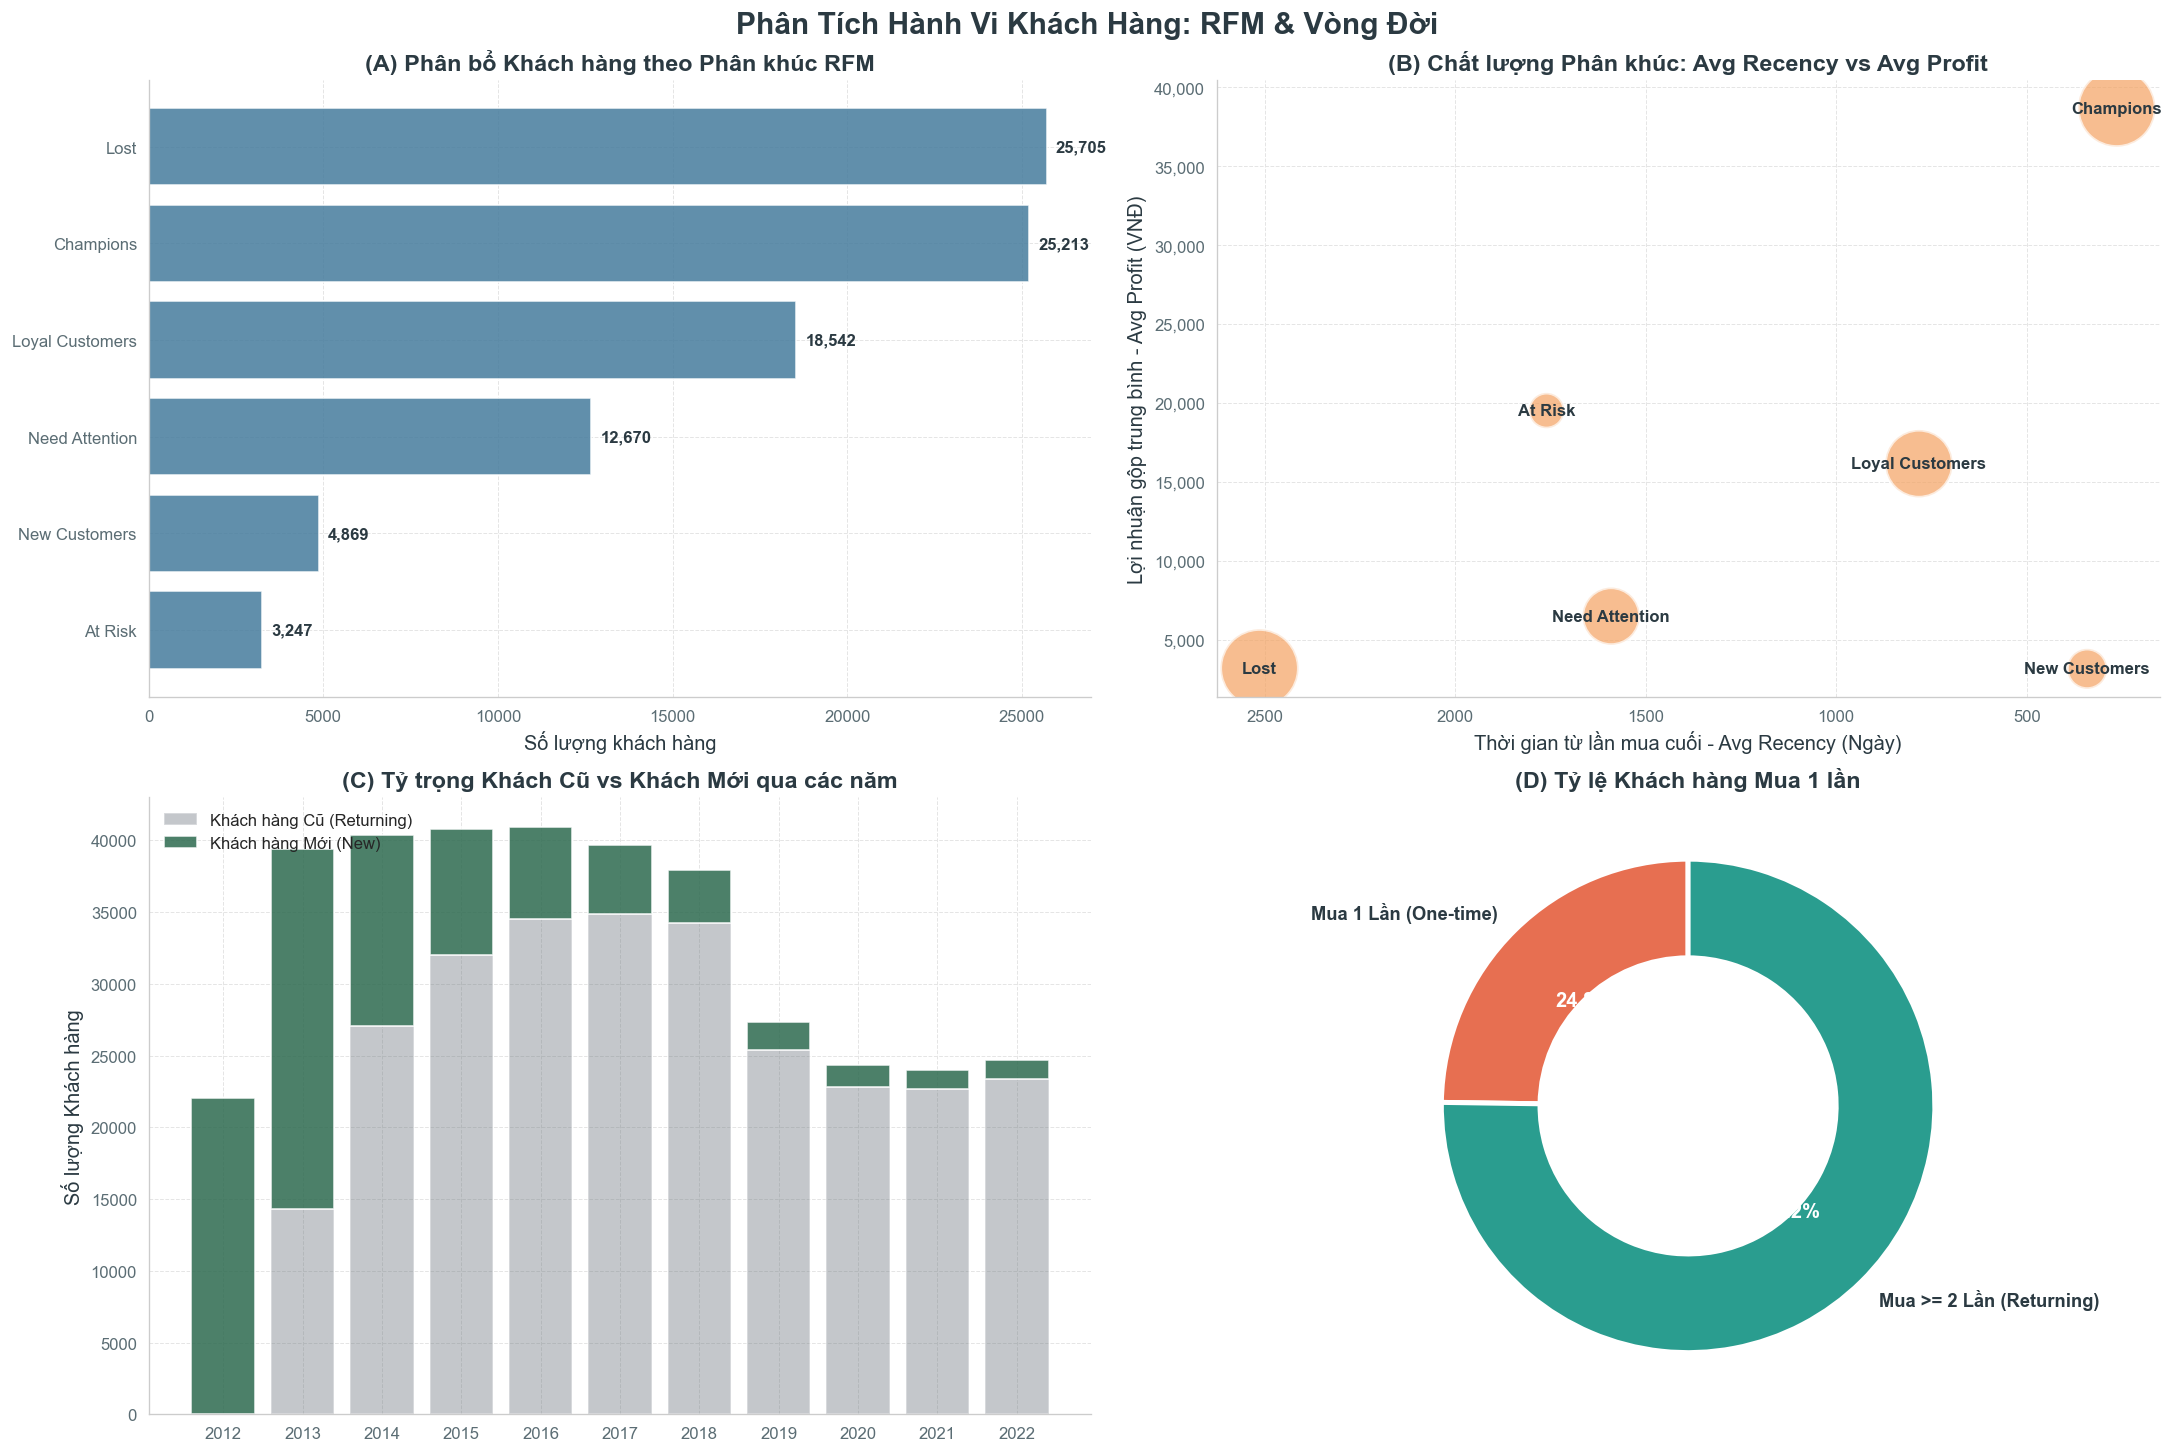

In [62]:
section_header(
    title='Phân tích khách hàng', 
    subtitle='RFM và tỷ lệ khách hàng 1 lần / khách mới - khách cũ'
)

# 1. Tính toán dữ liệu
customer_rfm = build_customer_rfm(master_df)
customer_lifecycle = compute_customer_lifecycle(master_df)

# 2. Thay thế toàn bộ print và display bằng hàm vẽ biểu đồ
plot_customer_behavior_dashboard(
    customer_rfm=customer_rfm, 
    customer_lifecycle=customer_lifecycle, 
    save_fig=True
)

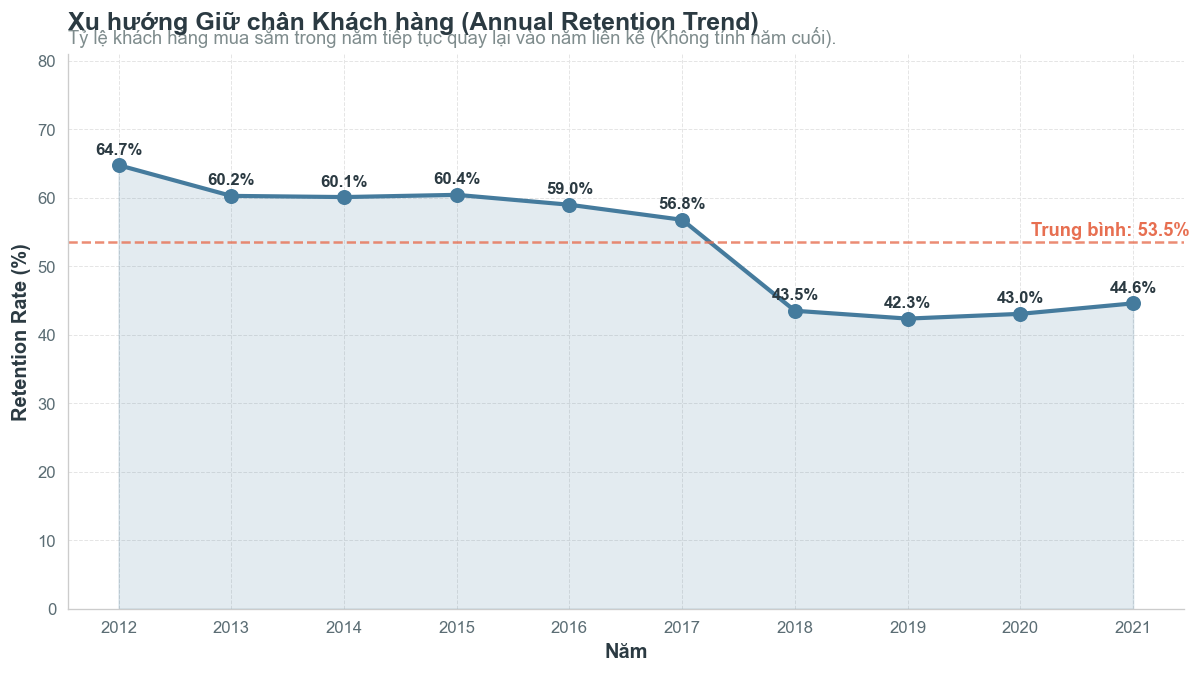

In [63]:
section_header(
    title='Phân tích Rời bỏ & Giữ chân (Churn & Retention)', 
    subtitle='Đánh giá sự ổn định của tập khách hàng và khả năng quay lại mua sắm qua các năm'
)

# Chạy hàm vẽ biểu đồ
plot_annual_retention_trend(master_df=master_df, save_fig=True)

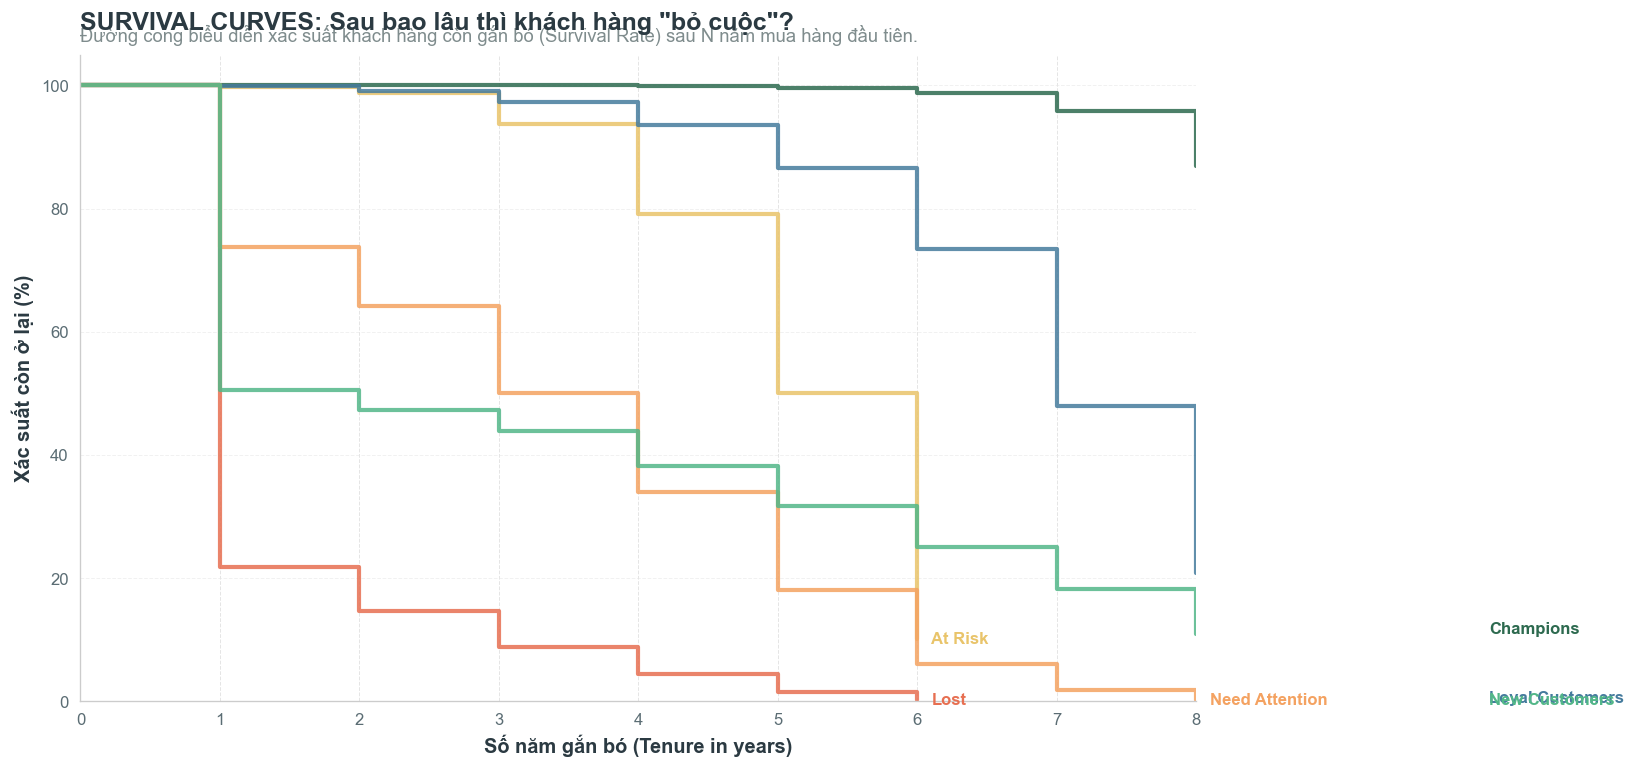

In [64]:
section_header(
    title='Phân tích Dự báo: Mô hình Sinh tồn (Survival Analysis)', 
    subtitle='Dự đoán rủi ro rời bỏ của từng phân khúc khách hàng qua các năm'
)

# Yêu cầu biến customer_rfm đã tồn tại trong môi trường từ bước trước
plot_customer_survival_analysis(
    master_df=master_df, 
    customer_rfm=customer_rfm, 
    save_fig=True
)

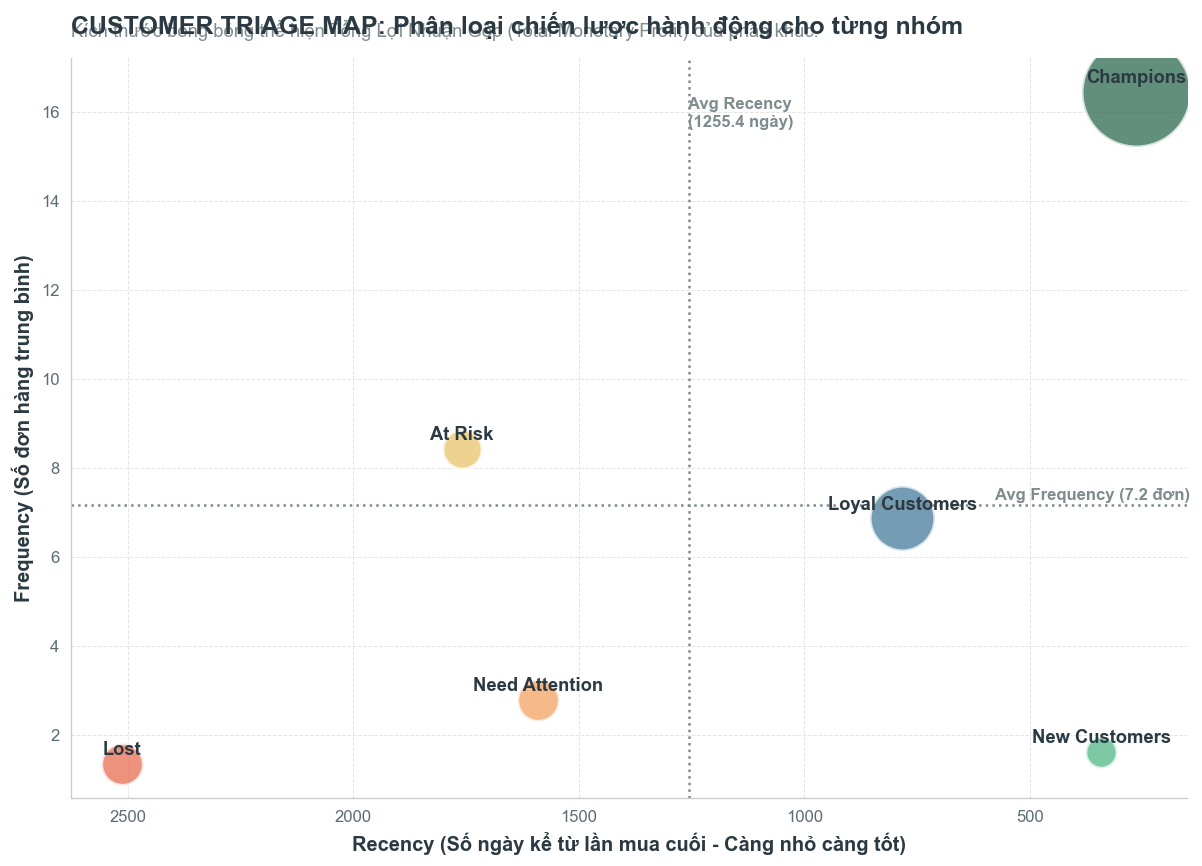

In [65]:
section_header(
    title='Ma trận Ưu tiên Khách hàng (Customer Triage Map)', 
    subtitle='Góc phần tư phía trên bên phải là nhóm Khách hàng lý tưởng. Kích thước bong bóng là Tổng Lợi nhuận.'
)

# Sử dụng dữ liệu customer_rfm đã có
plot_customer_triage_map(
    customer_rfm=customer_rfm, 
    save_fig=True
)

---

## 6. Tổng kết chiến lược

### Kết luận sơ bộ
- Doanh nghiệp có áp lực tồn kho kép: tỷ lệ stockout và overstock together phản ánh mất cân đối vận hành.
- Tỷ lệ hủy đơn, hoàn hàng và chi phí hoàn tiền cần được ưu tiên vì ảnh hưởng trực tiếp tới biên lợi nhuận.
- Khuyến mãi có độ thâm nhập cao nhưng biên lợi nhuận thấp hơn mặt bằng chung, cần rà soát chiến lược promo.
- Phân tích khách hàng cho thấy nhóm khách hàng mua 1 lần cần được chăm sóc riêng để cải thiện retention.